# Week 7
The following notebook provides a cleaned version of data I want to use for the midterm.  I identify neighborhoods in the top quratile of Ellis Act filings per number of RSOs per neighborhood.  I create a loop mapping top quartile neighborhoods.

## Upload and join data

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [45]:
# Load LA Neighborhood Boundaries
import geopandas as gpd

# Set the file path to your local LA Times Neighborhood Boundaries file
neighborhoods_path = "LA_Times_Neighborhood_Boundaries.geojson"  # Update this with the actual file path

# Load the neighborhood boundaries from the local file
neighborhoods = gpd.read_file(neighborhoods_path)

# Print the first few rows to verify
print(neighborhoods.head())


   OBJECTID                    name  \
0         1         Adams-Normandie   
1         2                  Arleta   
2         3       Arlington Heights   
3         4         Atwater Village   
4         5  Baldwin Hills/Crenshaw   

                                            geometry  
0  POLYGON ((-118.30069 34.03731, -118.30388 34.0...  
1  POLYGON ((-118.44255 34.26412, -118.4424 34.26...  
2  POLYGON ((-118.31862 34.05306, -118.31673 34.0...  
3  MULTIPOLYGON (((-118.27886 34.15321, -118.2788...  
4  POLYGON ((-118.36102 34.02532, -118.36026 34.0...  


In [46]:
# Load RSO Data
rso_data_path = 'RSO_Total_Geocoded_Final.csv'  # Replace with your file path
rso_data = pd.read_csv(rso_data_path)
rso_gdf = gpd.GeoDataFrame(rso_data, geometry=gpd.points_from_xy(rso_data.Longitude, rso_data.Latitude), crs='EPSG:4326')

In [47]:
# Load Ellis Act Filings Data
ellis_data_path = 'Ellis Act.csv'  # Replace with your file path
ellis_data = pd.read_csv(ellis_data_path)
ellis_gdf = gpd.GeoDataFrame(ellis_data, geometry=gpd.points_from_xy(ellis_data.Longitude, ellis_data.Latitude), crs='EPSG:4326')


In [48]:
# Spatial Join: Assign RSO and Ellis Act filings to neighborhoods
rso_neighborhoods = gpd.sjoin(rso_gdf, neighborhoods, how='left', predicate='within')
ellis_neighborhoods = gpd.sjoin(ellis_gdf, neighborhoods, how='left', predicate='within')

## Calculate the top quartile
Calculate neighborhoods in the top quartile of RSO removals.

In [49]:
# Calculate the percentage of RSO units withdrawn via Ellis Act by neighborhood
rso_counts = rso_neighborhoods['name'].value_counts()
ellis_counts = ellis_neighborhoods['name'].value_counts()
withdrawal_percentage = (ellis_counts / rso_counts) * 100
withdrawal_percentage = withdrawal_percentage.fillna(0)  # Replace NaN with 0 for neighborhoods with no Ellis Act filings

In [50]:
# Merge percentage data back to neighborhoods GeoDataFrame
neighborhoods['withdrawal_percentage'] = neighborhoods['name'].map(withdrawal_percentage)

In [51]:
# Identify top quartile neighborhoods
top_quartile_threshold = withdrawal_percentage.quantile(0.75)
top_quartile_neighborhoods = neighborhoods[neighborhoods['withdrawal_percentage'] >= top_quartile_threshold]

In [52]:
from tabulate import tabulate

# Ensure the withdrawal percentage DataFrame is correctly structured
withdrawal_percentage_df = withdrawal_percentage.reset_index()
withdrawal_percentage_df.columns = ['Neighborhood', 'Withdrawal Percentage']

# Calculate the top quartile threshold
top_quartile_threshold = withdrawal_percentage_df['Withdrawal Percentage'].quantile(0.75)

# Filter to only include top quartile neighborhoods
top_quartile_df = withdrawal_percentage_df[withdrawal_percentage_df['Withdrawal Percentage'] >= top_quartile_threshold]

# Sort by withdrawal percentage in ascending order
top_quartile_df = top_quartile_df.sort_values(by='Withdrawal Percentage', ascending=True)

# Format the percentage values to show up to two decimal places
top_quartile_df['Withdrawal Percentage'] = top_quartile_df['Withdrawal Percentage'].round(2)

# Print the table with grid lines
print(tabulate(top_quartile_df, headers='keys', tablefmt='grid'))


+-----+------------------------+-------------------------+
|     | Neighborhood           |   Withdrawal Percentage |
+=====+========================+=========================+
|   2 | Arlington Heights      |                    3.65 |
+-----+------------------------+-------------------------+
|   0 | Adams-Normandie        |                    3.68 |
+-----+------------------------+-------------------------+
| 102 | West Adams             |                    3.86 |
+-----+------------------------+-------------------------+
|  83 | Silver Lake            |                    3.94 |
+-----+------------------------+-------------------------+
|  50 | Koreatown              |                    3.96 |
+-----+------------------------+-------------------------+
|  80 | Sepulveda Basin        |                    4.23 |
+-----+------------------------+-------------------------+
| 105 | Westchester            |                    4.27 |
+-----+------------------------+------------------------

## Maps
Create maps and a loop of the top quartile neighborhoods.

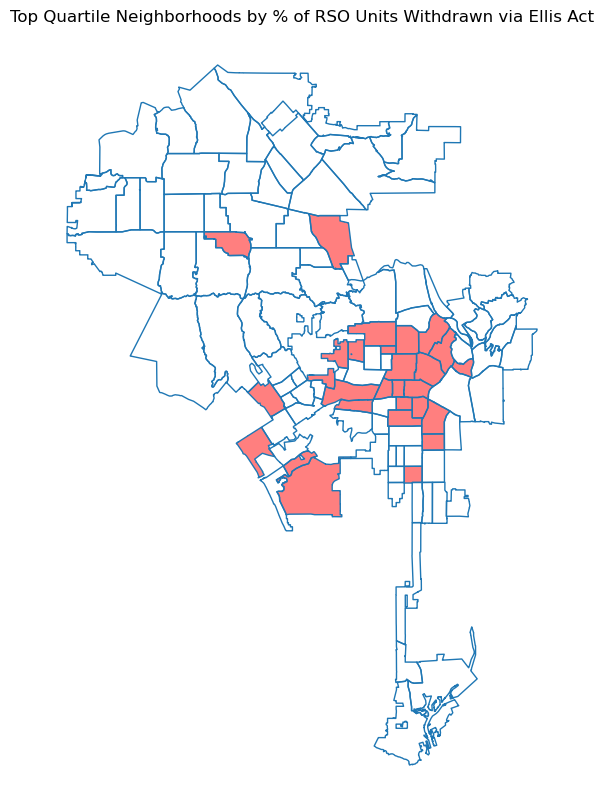

In [58]:
# Plot neighborhoods in the top quartile
fig, ax = plt.subplots(figsize=(10, 10))
neighborhoods.boundary.plot(ax=ax, linewidth=1)
top_quartile_neighborhoods.plot(ax=ax, color='red', alpha=0.5)
plt.title('Top Quartile Neighborhoods by % of RSO Units Withdrawn via Ellis Act')
ax.set_axis_off()
plt.show()

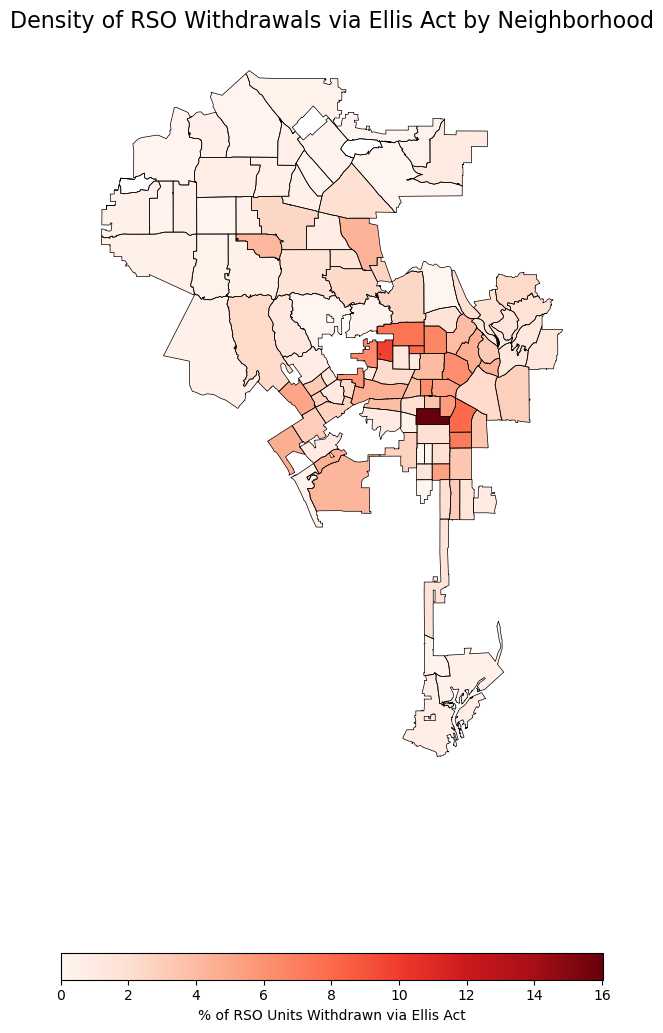

In [72]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Ensure the geometry column is correctly set
if "geometry" not in neighborhoods.columns:
    raise ValueError("The dataset does not contain a 'geometry' column. Cannot proceed with plotting.")

neighborhoods = neighborhoods.set_geometry("geometry")

# Create a density map for all neighborhoods with a light-to-dark red colormap
fig, ax = plt.subplots(figsize=(14, 14))  # Increase figure size for better visibility

# Plot the full neighborhood boundary in black to create a border
neighborhoods.boundary.plot(ax=ax, linewidth=0.5, color="black")

# Use the 'Reds' colormap to achieve a light-to-dark red gradient
neighborhoods.plot(column='withdrawal_percentage', ax=ax, legend=True,
                       cmap='Reds',  # Light-to-dark red color gradient
                       legend_kwds={'label': "% of RSO Units Withdrawn via Ellis Act",
                                    'orientation': "horizontal",
                                    'shrink': 0.5})  # Reduce legend size

# Add title and remove axis borders
plt.title('Density of RSO Withdrawals via Ellis Act by Neighborhood', fontsize=16)
ax.set_axis_off()  # Hide grid and axis labels

# Show the plot
plt.show()


/opt/conda/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


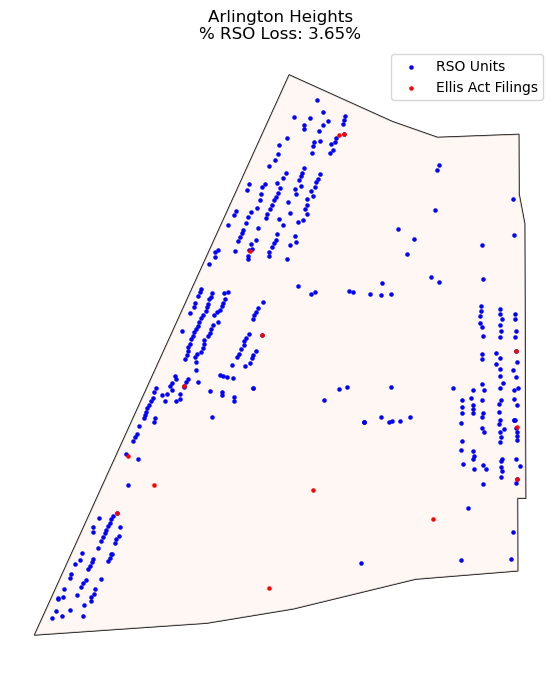

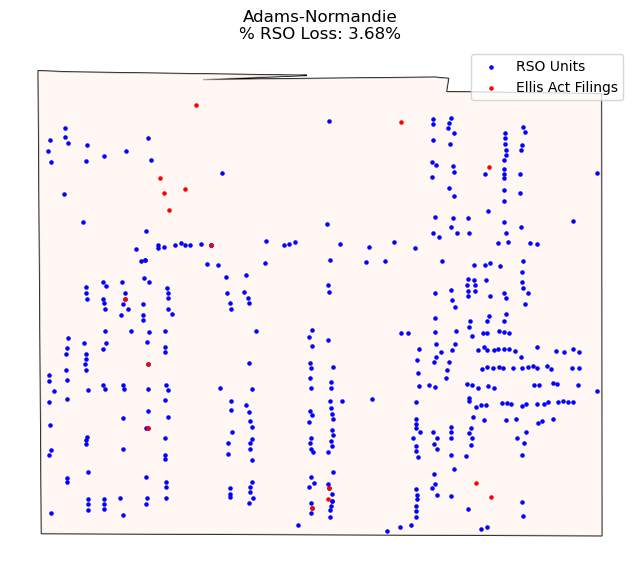

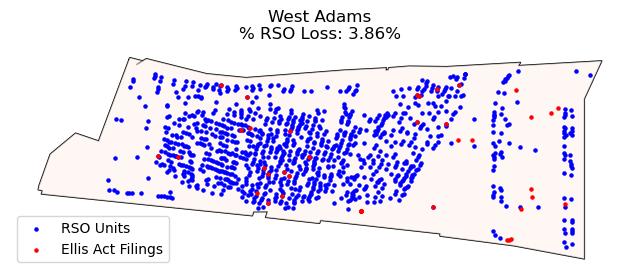

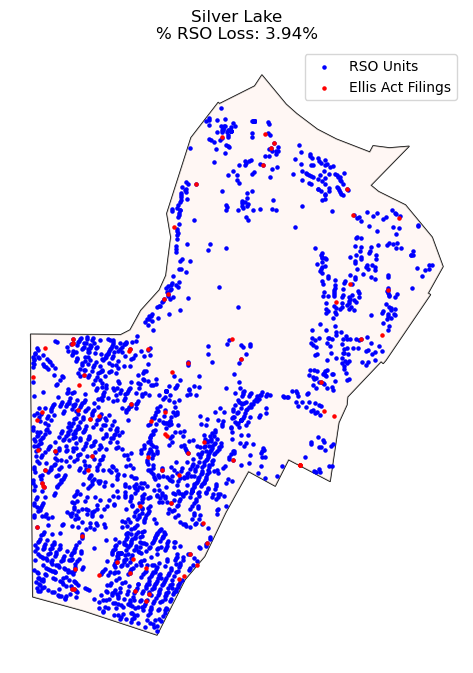

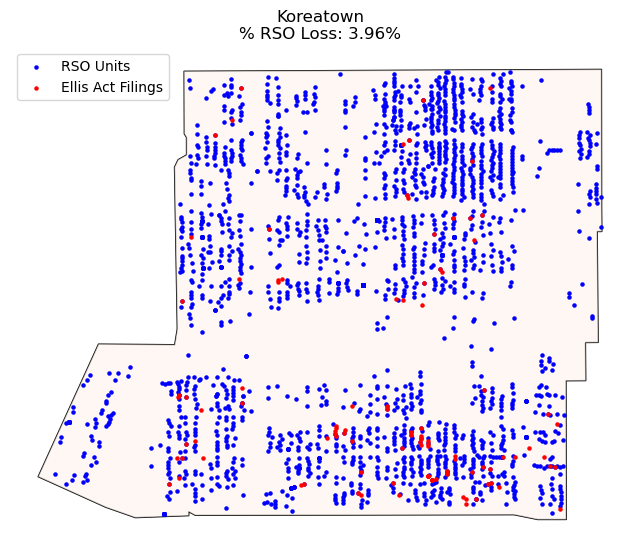

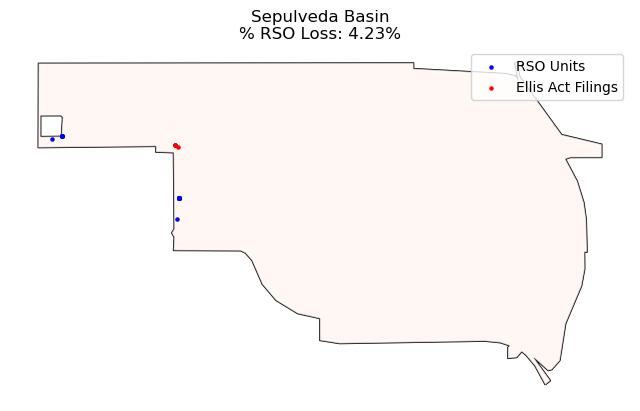

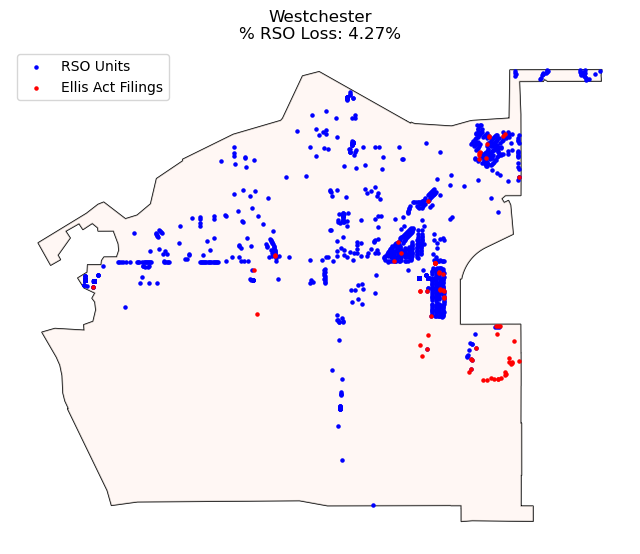

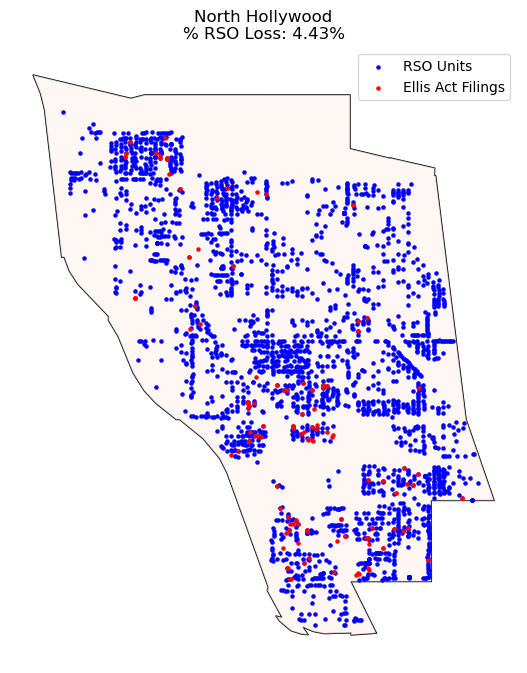

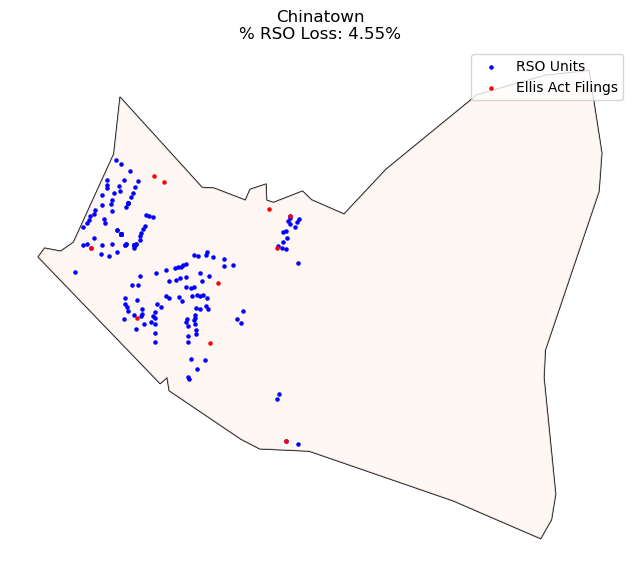

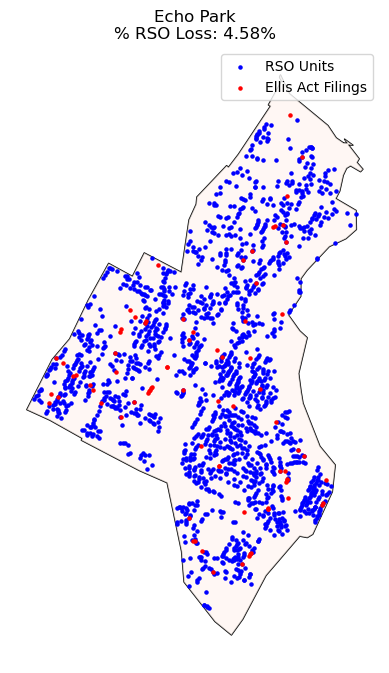

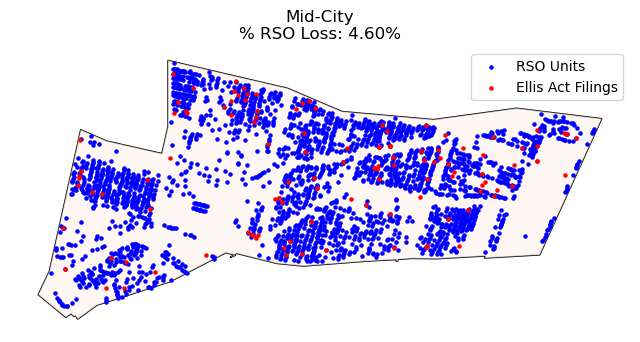

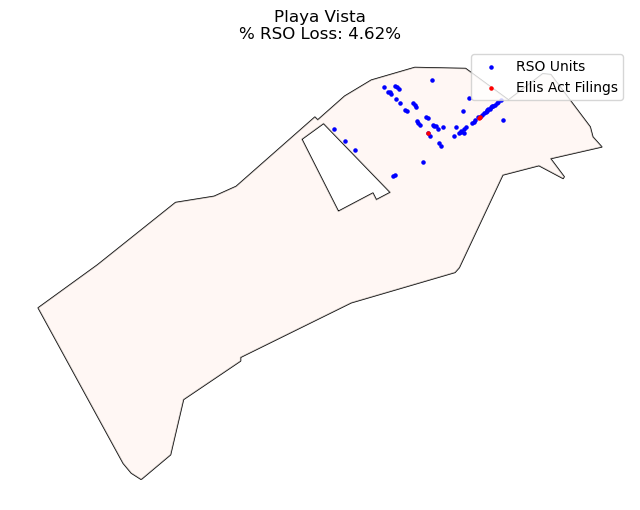

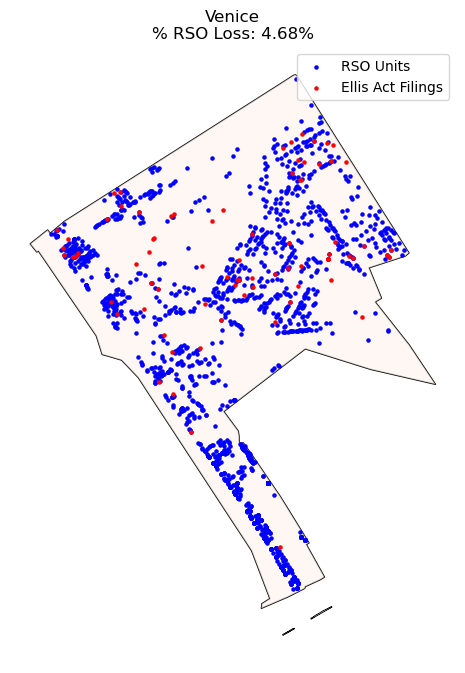

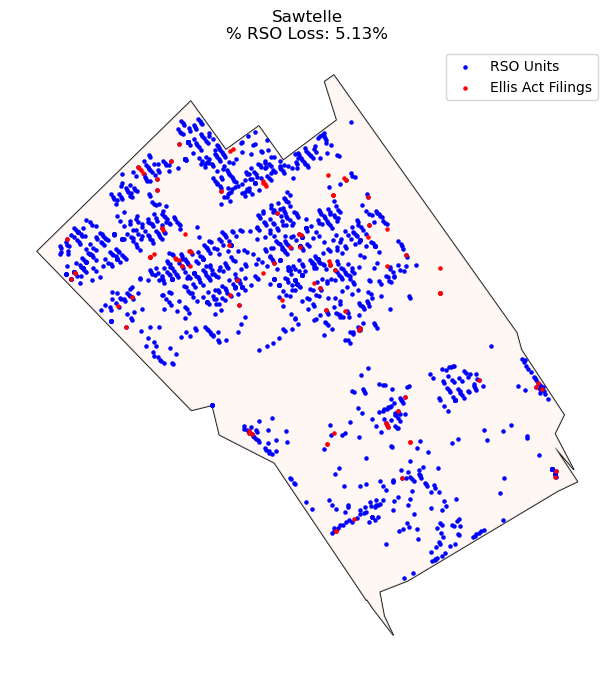

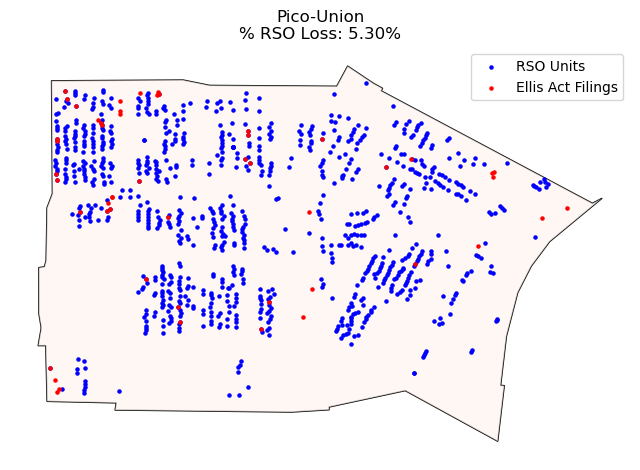

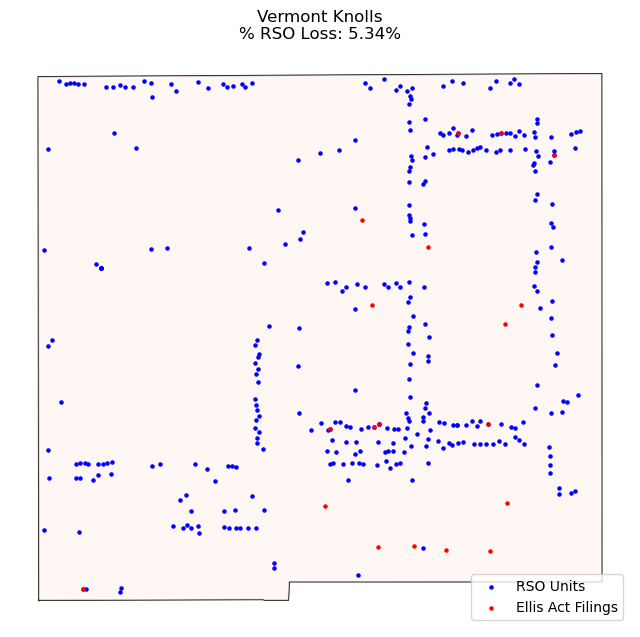

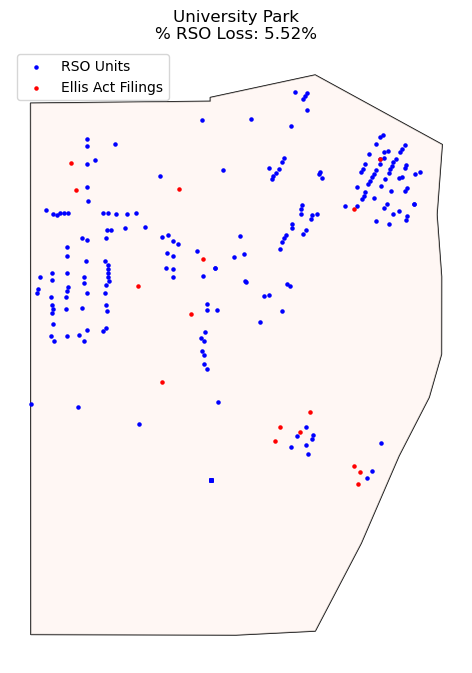

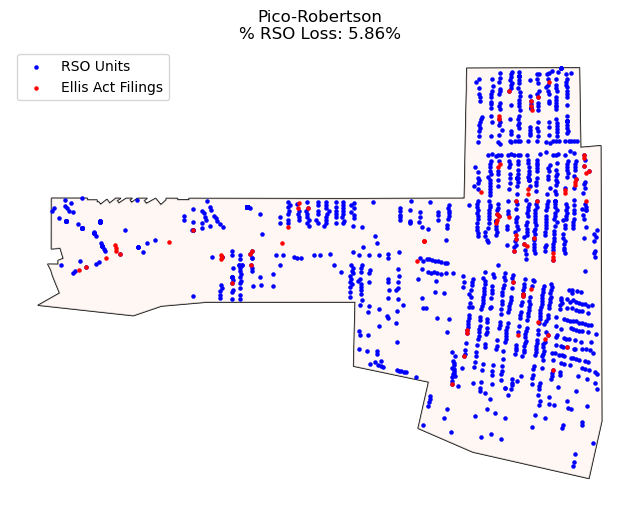

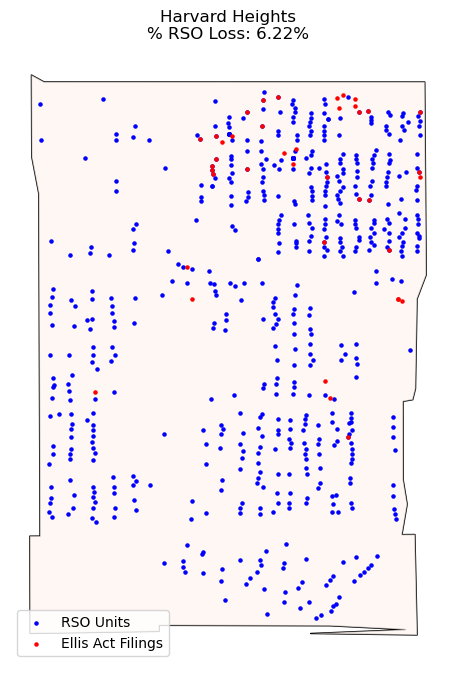

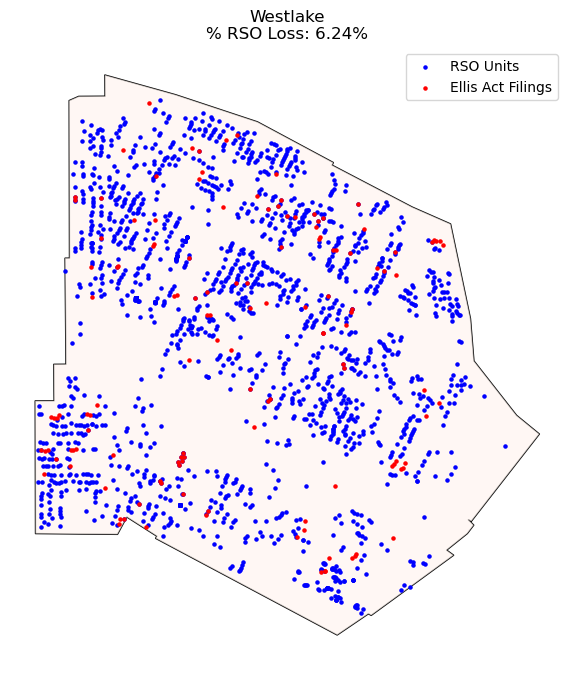

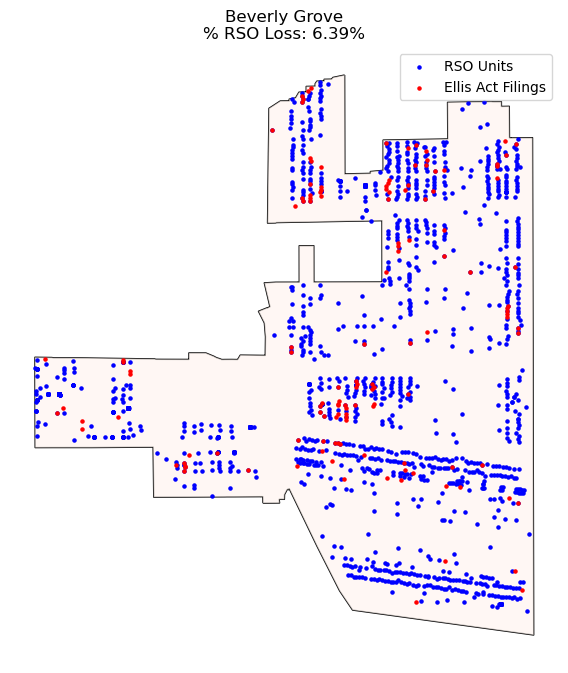

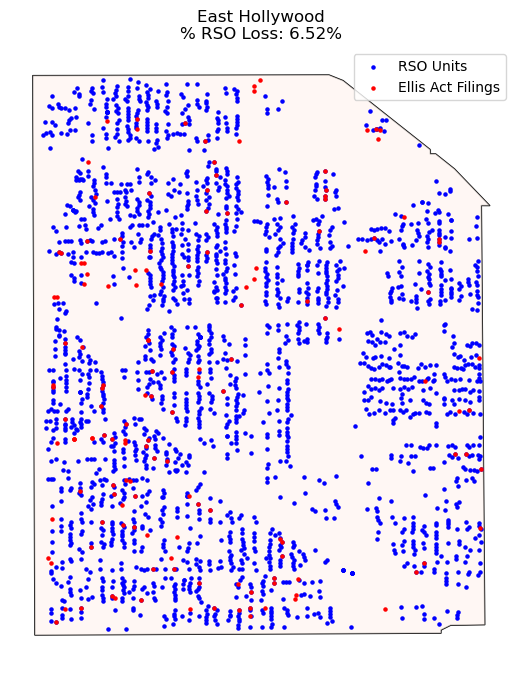

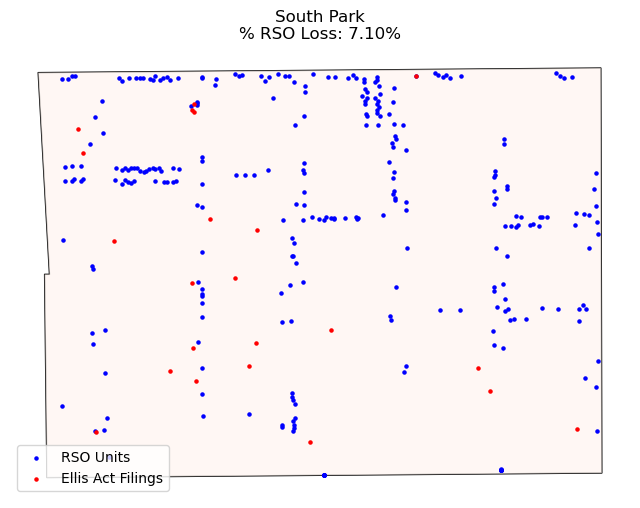

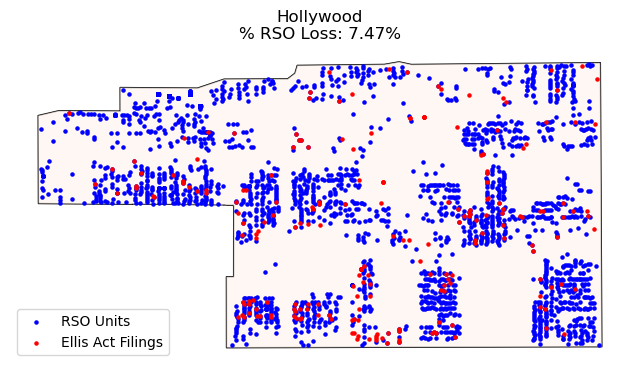

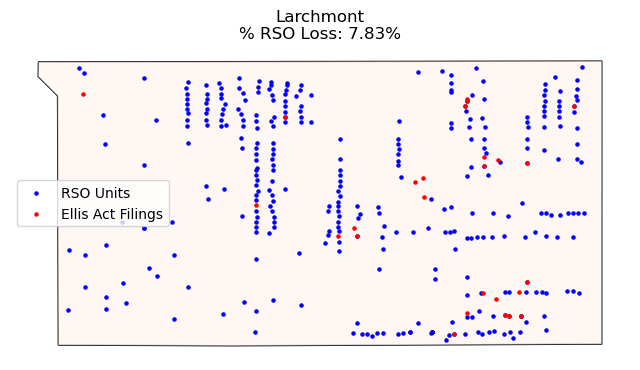

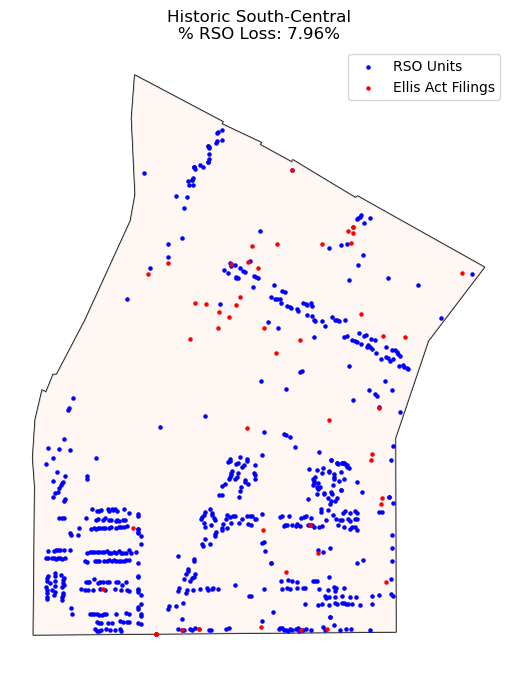

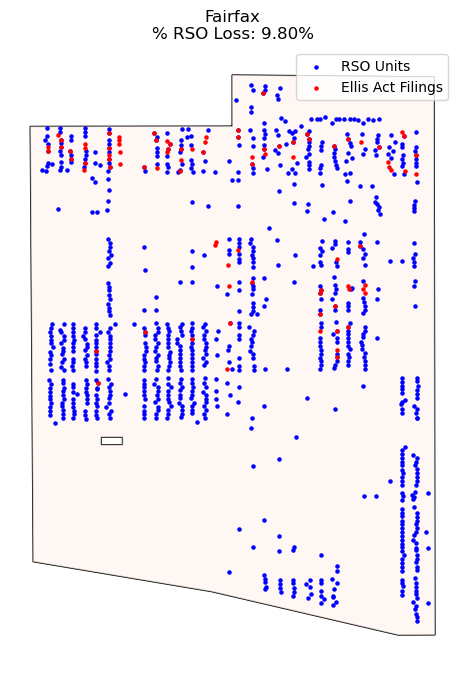

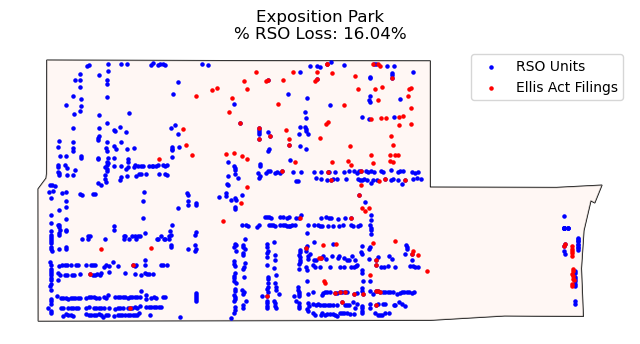

In [76]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd

# Ensure neighborhoods is a GeoDataFrame
if not isinstance(neighborhoods, gpd.GeoDataFrame):
    neighborhoods = gpd.GeoDataFrame(neighborhoods, geometry="geometry", crs="EPSG:4326")

# Ensure 'withdrawal_percentage' is numeric and handle NaN values
neighborhoods["withdrawal_percentage"] = pd.to_numeric(neighborhoods["withdrawal_percentage"], errors="coerce")
neighborhoods = neighborhoods.dropna(subset=["withdrawal_percentage"])  # Drop rows where withdrawal % is NaN

# Ensure quartiles exist in the dataset
if "quartile" not in neighborhoods.columns:
    quartiles = np.percentile(neighborhoods["withdrawal_percentage"].dropna(), [25, 50, 75])  # Drop NaNs before computing quartiles
    quartiles = np.sort(quartiles)  # Ensure quartiles are in increasing order
    labels = ["Q1 (0-25%)", "Q2 (25-50%)", "Q3 (50-75%)", "Q4 (75-100%)"]

    neighborhoods.loc[:, "quartile"] = pd.cut(
        neighborhoods["withdrawal_percentage"],
        bins=[-np.inf, quartiles[0], quartiles[1], quartiles[2], np.inf],
        labels=labels
    )

# Filter top quartile neighborhoods and sort from lowest to highest withdrawal percentage
top_quartile_neighborhoods = neighborhoods[neighborhoods["quartile"] == "Q4 (75-100%)"].sort_values(
    by="withdrawal_percentage", ascending=True
)

# Generate individual maps for top quartile neighborhoods with density and percentage labels
for idx, row in top_quartile_neighborhoods.iterrows():
    fig, ax = plt.subplots(figsize=(8, 8))

    # Select the specific neighborhood and ensure it remains a GeoDataFrame
    neighborhood = neighborhoods[neighborhoods['name'] == row['name']]

    if not isinstance(neighborhood, gpd.GeoDataFrame):
        neighborhood = gpd.GeoDataFrame(neighborhood, geometry="geometry", crs="EPSG:4326")

    # Plot the boundary of the neighborhood
    neighborhood.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)

    # Plot the neighborhood filled with density color
    neighborhood.plot(ax=ax, column='withdrawal_percentage', cmap='Reds', alpha=0.7, legend=False)

    # Plot RSO units and Ellis Act filings within the neighborhood
    rso_in_neighborhood = rso_neighborhoods[rso_neighborhoods['name'] == row['name']]
    ellis_in_neighborhood = ellis_neighborhoods[ellis_neighborhoods['name'] == row['name']]
    rso_in_neighborhood.plot(ax=ax, color='blue', markersize=5, label='RSO Units')
    ellis_in_neighborhood.plot(ax=ax, color='red', markersize=5, label='Ellis Act Filings')

    # Add title with neighborhood name and RSO withdrawal percentage
    withdrawal_percentage = row["withdrawal_percentage"]
    plt.title(f"{row['name']}\n% RSO Loss: {withdrawal_percentage:.2f}%", fontsize=12)

    # Remove axis
    ax.set_axis_off()

    # Show the map
    plt.legend()
    plt.show()
